In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import openpyxl

In [13]:
# Load dataset
df = pd.read_excel(r"C:\Users\ATbru\Downloads\CODE\AI_ML_DL\Algo\Datasets\heartdisease.xlsx")

# Explore dataset
print("Dataset Info:")
print(df.info())
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing values:")
print(df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   age           19 non-null     int64
 1   Gender        19 non-null     int64
 2   Family        19 non-null     int64
 3   diet          19 non-null     int64
 4   Lifestyle     19 non-null     int64
 5   cholestrol    19 non-null     int64
 6   heartdisease  19 non-null     int64
dtypes: int64(7)
memory usage: 1.2 KB
None

First 5 rows:
   age  Gender  Family  diet  Lifestyle  cholestrol  heartdisease
0    0       0       1     1          3           0             1
1    0       1       1     1          3           0             1
2    1       0       0     0          2           1             1
3    4       0       1     1          3           2             0
4    3       1       1     0          0           2             0

Missing values:
age             0
Gender          0
Family  

In [ ]:
# Preprocessing
# Handle missing values
df.fillna(df.mean(numeric_only=True), inplace=True)
df.fillna(df.mode().iloc[0], inplace=True)

X = df.drop('heartdisease', axis=1)
y = df['heartdisease']

In [ ]:
# Encode categorical features 
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Encode target 
if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
# Train Gaussian Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)

# Predict and evaluate
y_pred = nb.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)


Bayesian Classifier (Naive Bayes) Results:
Accuracy: 1.0000

Confusion Matrix:
[[1 0]
 [0 3]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         3

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



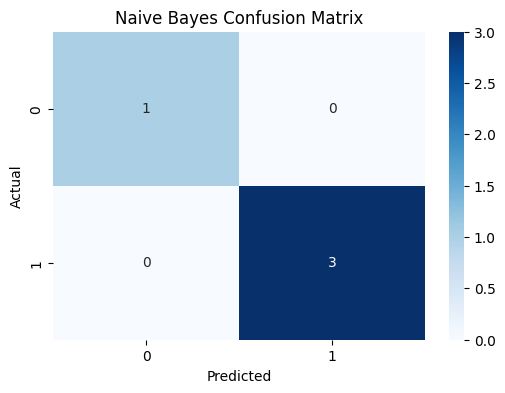

In [17]:
# Print results
print("\nBayesian Classifier (Naive Bayes) Results:")
print(f"Accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)

# Visualize confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Naive Bayes Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()